In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay,precision_recall_curve,average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# Step 1: Load and Preprocess Data
data = pd.read_csv("/kaggle/input/mimiciv/complete_data.csv")
X = data[['anchor_age', 'gender', 'hr', 'hr_alarm_h', 'hr_alarm_l', 'nbps', 'nbpd', 'nbpm', 'spo2', 'creatinine', 'glucose', 'sodium', 'nbp_alarm_h', 'nbp_alarm_l', 'temperaturef', 'sp02_alarm_h', 'sp02_alarm_l', 'resp_alarm_h', 'resp_alarm_l', 'calcium', 'spo02_desatlimit', 'weight', 'potassium', 'tobacco']]
y = data['is_hypertensive']

# Step 2: Resampling to Handle Imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 3: Scaling for models that require it (Logistic Regression, SVM)
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Step 4: Define classifiers with GPU support where possible
classifiers = {
    'XGBoost': xgb.XGBClassifier(device='cuda', n_jobs=-1, use_label_encoder=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, solver='saga', random_state=42),
    'Naive Bayes': GaussianNB()
}

# Function to evaluate models using K-Fold Cross-Validation
def evaluate_model(model, X, y, n_splits=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for train_idx, val_idx in kfold.split(X, y):
        # Check if X and y are DataFrames or arrays and handle accordingly
        if isinstance(X, pd.DataFrame):
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        else:
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        
        # Calculate metrics for each fold
        metrics['accuracy'].append(accuracy_score(y_val_fold, y_pred))
        metrics['precision'].append(precision_score(y_val_fold, y_pred, zero_division=1))
        metrics['recall'].append(recall_score(y_val_fold, y_pred))
        metrics['f1'].append(f1_score(y_val_fold, y_pred))
    
    # Calculate the average of each metric across all folds
    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    return avg_metrics

In [27]:
# Step 5: Train and Evaluate Classifiers using K-Fold Cross-Validation
results = []
for name, clf in classifiers.items():
    print(f"Evaluating {name}...")
    if name in ['Logistic Regression']:
        metrics = evaluate_model(clf, X_train_resampled_scaled, y_train_resampled)
    else:
        metrics = evaluate_model(clf, X_train_resampled, y_train_resampled)
    
    results.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1']
    })

results_df = pd.DataFrame(results)
print("Initial Model Performance:\n", results_df)

Evaluating XGBoost...
Evaluating Random Forest...
Evaluating Logistic Regression...
Evaluating Naive Bayes...
Initial Model Performance:
                  Model  Accuracy  Precision    Recall  F1 Score
0              XGBoost  0.813253   0.835087  0.780636  0.806894
1        Random Forest  0.822880   0.832036  0.808903  0.820296
2  Logistic Regression  0.669479   0.664444  0.685303  0.674597
3          Naive Bayes  0.589884   0.555598  0.910973  0.689809


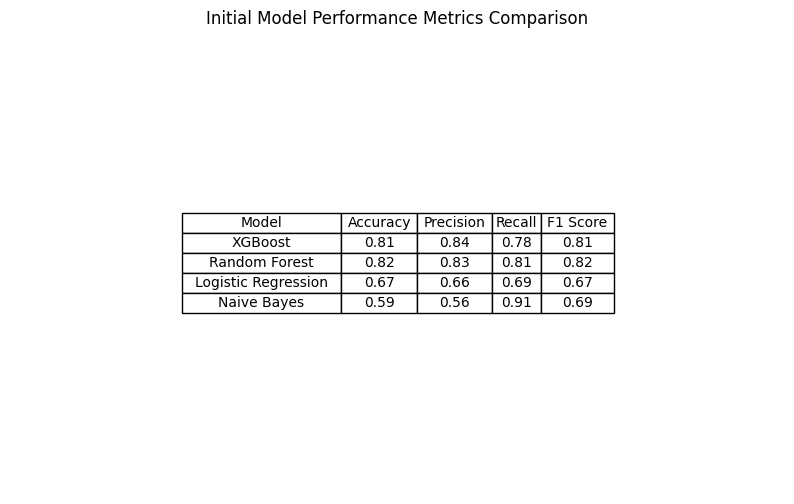

In [79]:
# Convert the results to a DataFrame
results_df = pd.DataFrame(results)

# Display the table as a plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')  # Turn off the axis

# Create a table plot from results_df
table = ax.table(cellText=results_df.round(2).values, colLabels=results_df.columns, cellLoc='center', loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(results_df.columns))))
table.scale(1.2, 1.2)  # Adjust scale for readability

plt.title("Initial Model Performance Metrics Comparison")
plt.savefig("/kaggle/working/initial_model_performance_table.jpg")
plt.show()

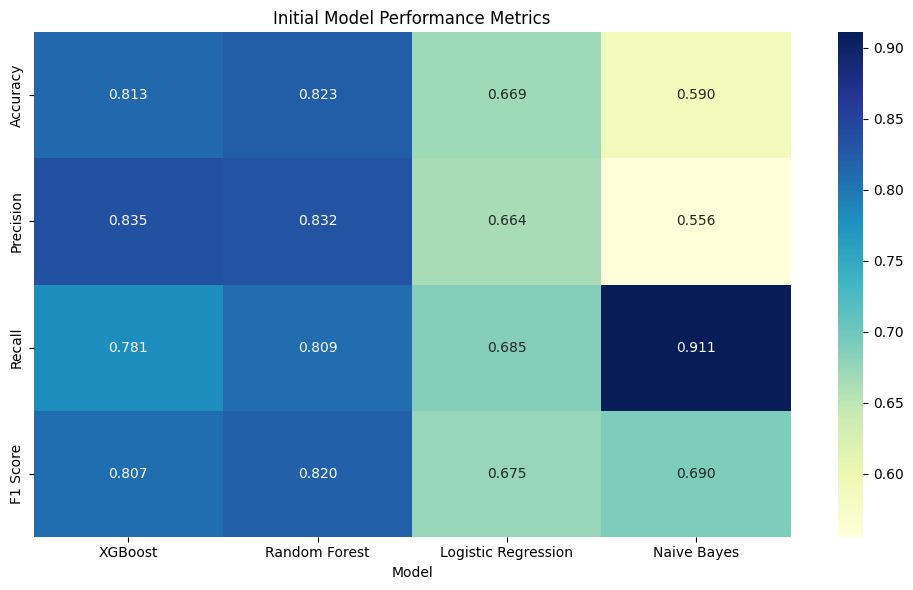

In [39]:
# Assuming `results_df` contains the initial model performance metrics
plt.figure(figsize=(10, 6))
sns.heatmap(results_df.set_index('Model').T, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Initial Model Performance Metrics")
# Save the plot as an image file
plt.tight_layout()
plt.savefig("/kaggle/working/heatmap.jpg")
plt.show()

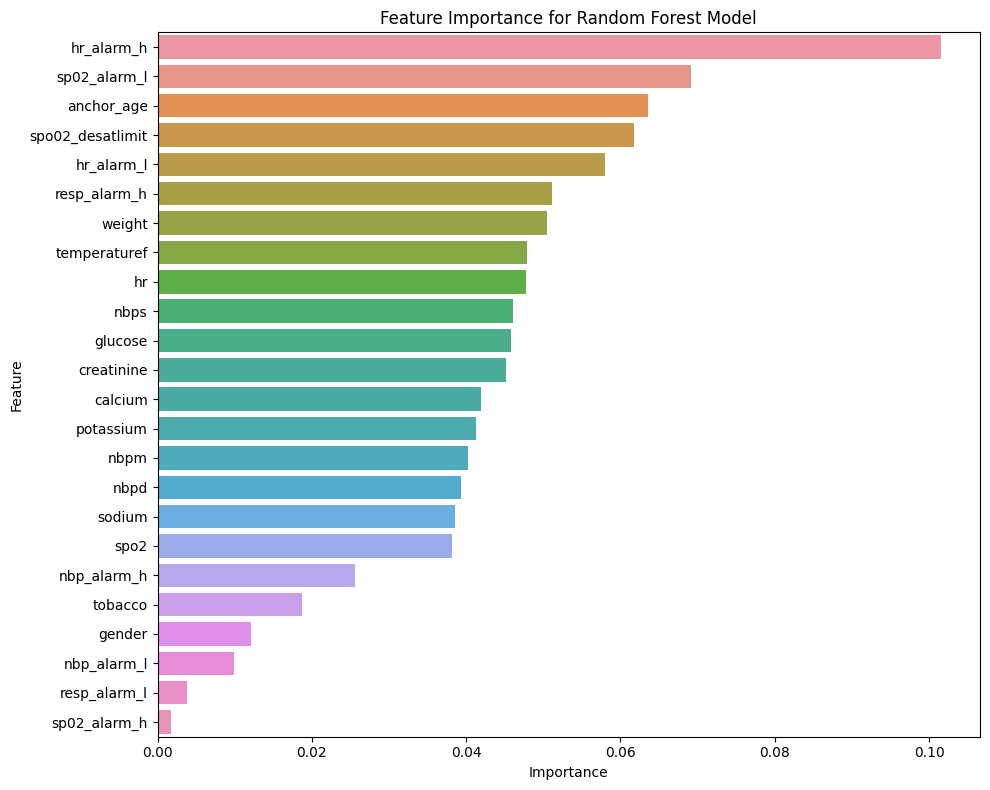

In [72]:
# Train Random Forest on the resampled training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_
feature_names = X.columns  # Assuming X is the original feature set before splitting

# Create a DataFrame to pair feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance for Random Forest Model")

plt.tight_layout()
plt.savefig("/kaggle/working/feature_importance.jpg")
plt.show()

<Figure size 600x600 with 0 Axes>

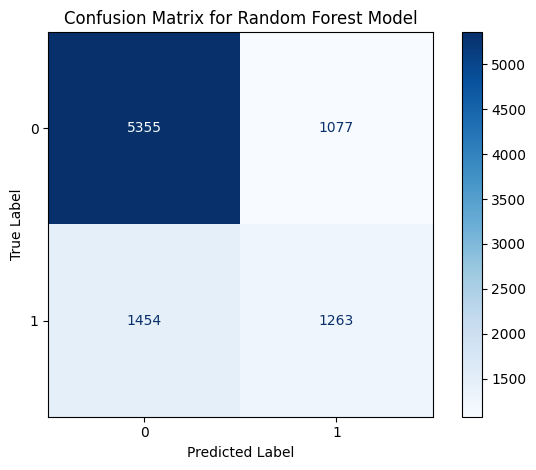

In [73]:
# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Blues")
plt.title("Confusion Matrix for Random Forest Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion matrix.jpg")
plt.show()

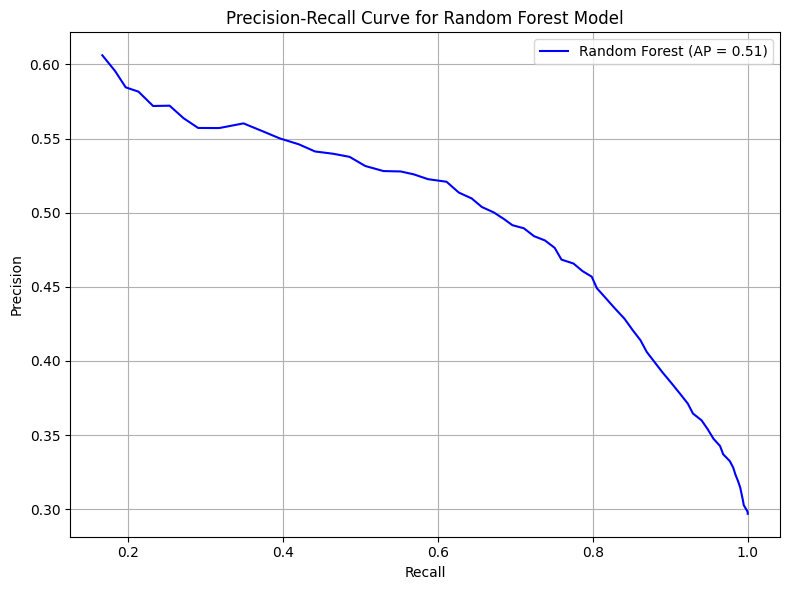

In [74]:
# Predict probabilities on the test set
y_scores = classifiers['Random Forest'].predict_proba(X_test)[:, 1]  # Get probability for the positive class

# Calculate precision and recall values for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
precision, recall, thresholds = precision[:-30], recall[:-30], thresholds[:-30]
# Calculate the average precision score (AP) as a summary of the precision-recall curve
ap_score = average_precision_score(y_test, y_scores)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (AP = {ap_score:.2f})', color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest Model')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/PrecisionRecall_Curve.jpg")
plt.show()

Optimal F1-score: 0.5828571428571429
Optimal Threshold: 0.34
Confusion Matrix:
 [[4189 2243]
 [ 677 2040]]
F1 Score at Optimal Threshold: 0.5828571428571429


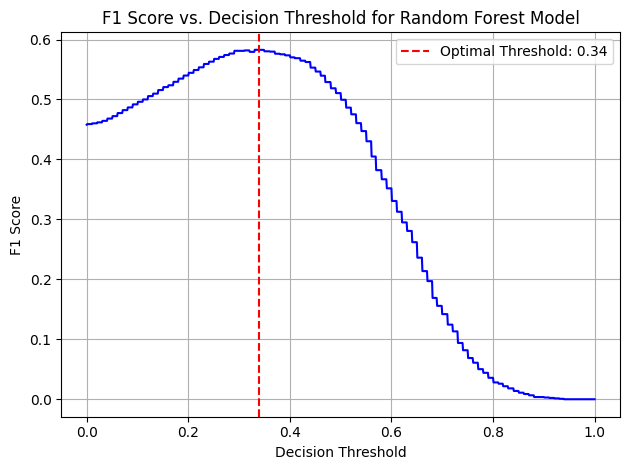

In [76]:
# Calculate F1 scores for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1 score
optimal_threshold_index = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_index]
optimal_f1_score = f1_scores[optimal_threshold_index]
print("Optimal F1-score:", optimal_f1_score)
print("Optimal Threshold:", optimal_threshold)

# Apply the optimal threshold to predictions
# Predict probabilities with Random Forest
y_scores_test = classifiers['Random Forest'].predict_proba(X_test)[:, 1]
y_pred_optimal = (y_scores_test >= optimal_threshold).astype(int)

# Display confusion matrix and F1 score at the optimal threshold
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optimal))
print("F1 Score at Optimal Threshold:", f1_score(y_test, y_pred_optimal))

# Function to calculate F1 score given a specific threshold
def f1(thresh):
    y_pred_thresh = (y_scores_test >= thresh).astype(int)
    return f1_score(y_test, y_pred_thresh)

# Plot F1 scores across different thresholds
l, r = 0.0, 1.0
thresholds_range = np.linspace(l, r, 1001)
f1_scores_range = [f1(thresh) for thresh in thresholds_range]

plt.plot(thresholds_range, f1_scores_range, color='b')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.ylabel("F1 Score")
plt.xlabel("Decision Threshold")
plt.title("F1 Score vs. Decision Threshold for Random Forest Model")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/F1_vs_Threshold.jpg")
plt.show()

In [ ]:
import shap

# Fit the model (as already done)
rf_model.fit(X_train_resampled, y_train_resampled)

# Create a SHAP explainer for the trained model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot for feature importance
shap.summary_plot(shap_values[1], X_test)